# AuroraBid · From probability estimates to bidding decisions

An executed walkthrough of **synthetic-data** modeling, point-in-time features, holdout evaluation, and API inference. The small training example below is separate from the full published benchmark, reproducible with `aurorabid reproduce`.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
from aurorabid.data import generate_data, chronological_split
from aurorabid.features import build_features, build_history, FEATURE_COLUMNS
from aurorabid.models import fit_models, save_models
ROOT = Path.cwd() if Path("pyproject.toml").exists() else Path.cwd().parent
assert (ROOT / "pyproject.toml").exists()
data = generate_data(n=2000, seed=2026)
display(data.opportunities.drop(columns=["market_price", "clicked", "converted"]).head())

,request_id,user_id,timestamp,age,segment,adslot_id,floor_price
0,req000000,u0129,2025-01-01 00:00:00+00:00,61,0,0,0.105125
1,req000001,u0247,2025-01-01 00:00:30+00:00,33,0,2,0.076742
2,req000002,u0007,2025-01-01 00:01:00+00:00,35,1,1,0.226158
3,req000003,u0040,2025-01-01 00:01:30+00:00,58,0,0,0.239464
4,req000004,u0083,2025-01-01 00:02:00+00:00,33,2,0,0.192806


## 1. Separate information from outcomes

Context is observable; competing prices and potential outcomes belong to the simulator. History is drawn from separate background events, available only after their own timestamps.

In [2]:
features = build_features(data.opportunities, data.activity)
changed = data.opportunities.copy()
changed["clicked"] = 1 - changed["clicked"]
changed["converted"] = 1 - changed["converted"]
changed["market_price"] *= 100
pd.testing.assert_frame_equal(features, build_features(changed, data.activity))
print("Changing target outcomes and market prices leaves all features unchanged.")
print("Shared feature count:", len(FEATURE_COLUMNS))
display(features.head())

Changing target outcomes and market prices leaves all features unchanged.
Shared feature count: 16


,age,segment_0,segment_1,segment_2,slot_0,slot_1,slot_2,slot_3,hour_sin,hour_cos,floor_price,prior_impressions,prior_clicks,prior_conversions,clicks_last_hour,seconds_since_click
0,0.61,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,1.000000,0.105125,2.484907,0.000000,0.000000,0.0,1.000000
1,0.33,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,1.000000,0.076742,2.564949,0.000000,0.000000,0.0,1.000000
2,0.35,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.004363,0.999990,0.226158,2.079442,0.000000,0.000000,0.0,1.000000
3,0.58,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.004363,0.999990,0.239464,2.772589,0.000000,0.000000,0.0,1.000000
4,0.33,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.008727,0.999962,0.192806,2.197225,0.693147,0.693147,0.0,0.978067


## 2. Select models on validation

CTR predicts clicks. CVR predicts conversion **conditional on a click**. Model selection uses validation log loss; named features are shared with API inference.

In [3]:
overlap = list(set(features.columns) & set(data.opportunities.columns))
frame = data.opportunities.drop(columns=overlap).join(features)
train, validation, test = chronological_split(frame)
models, validation_metrics = fit_models(train, validation)
print(f"Small walkthrough split: {len(train)} / {len(validation)} / {len(test)}")
display(pd.DataFrame(validation_metrics))

Small walkthrough split: 1200 / 400 / 400


,target,model,split,auc,log_loss,brier,n
0,ctr,logistic,validation,0.661877,0.362391,0.104157,400
1,ctr,boosted,validation,0.599730,0.401560,0.119390,400
2,cvr,logistic,validation,0.483117,0.638913,0.225164,46
3,cvr,boosted,validation,0.361039,0.668318,0.228673,46


## 3. Inspect the full benchmark

These committed results come from 15,000 opportunities, including 3,000 test examples with a 1,050-unit budget. They are not the results of the small training example above. Learned policies have three training seeds; fixed baselines have one run.

,policy,seed,wins,conversions,spend,profit,budget_utilization
0,Constant bid,NaN,1800,55,1049.901,600.099,1.000
1,Value-based,NaN,1040,74,611.693,1608.307,0.583
2,LinUCB,42.0,1479,87,990.188,1619.812,0.943
3,PPO,42.0,1709,82,1049.809,1410.191,1.000
4,LinUCB,43.0,1472,83,1049.971,1440.029,1.000
5,PPO,43.0,1709,82,1049.809,1410.191,1.000
6,LinUCB,44.0,1490,80,983.946,1416.054,0.937
7,PPO,44.0,1625,59,1049.971,720.029,1.000


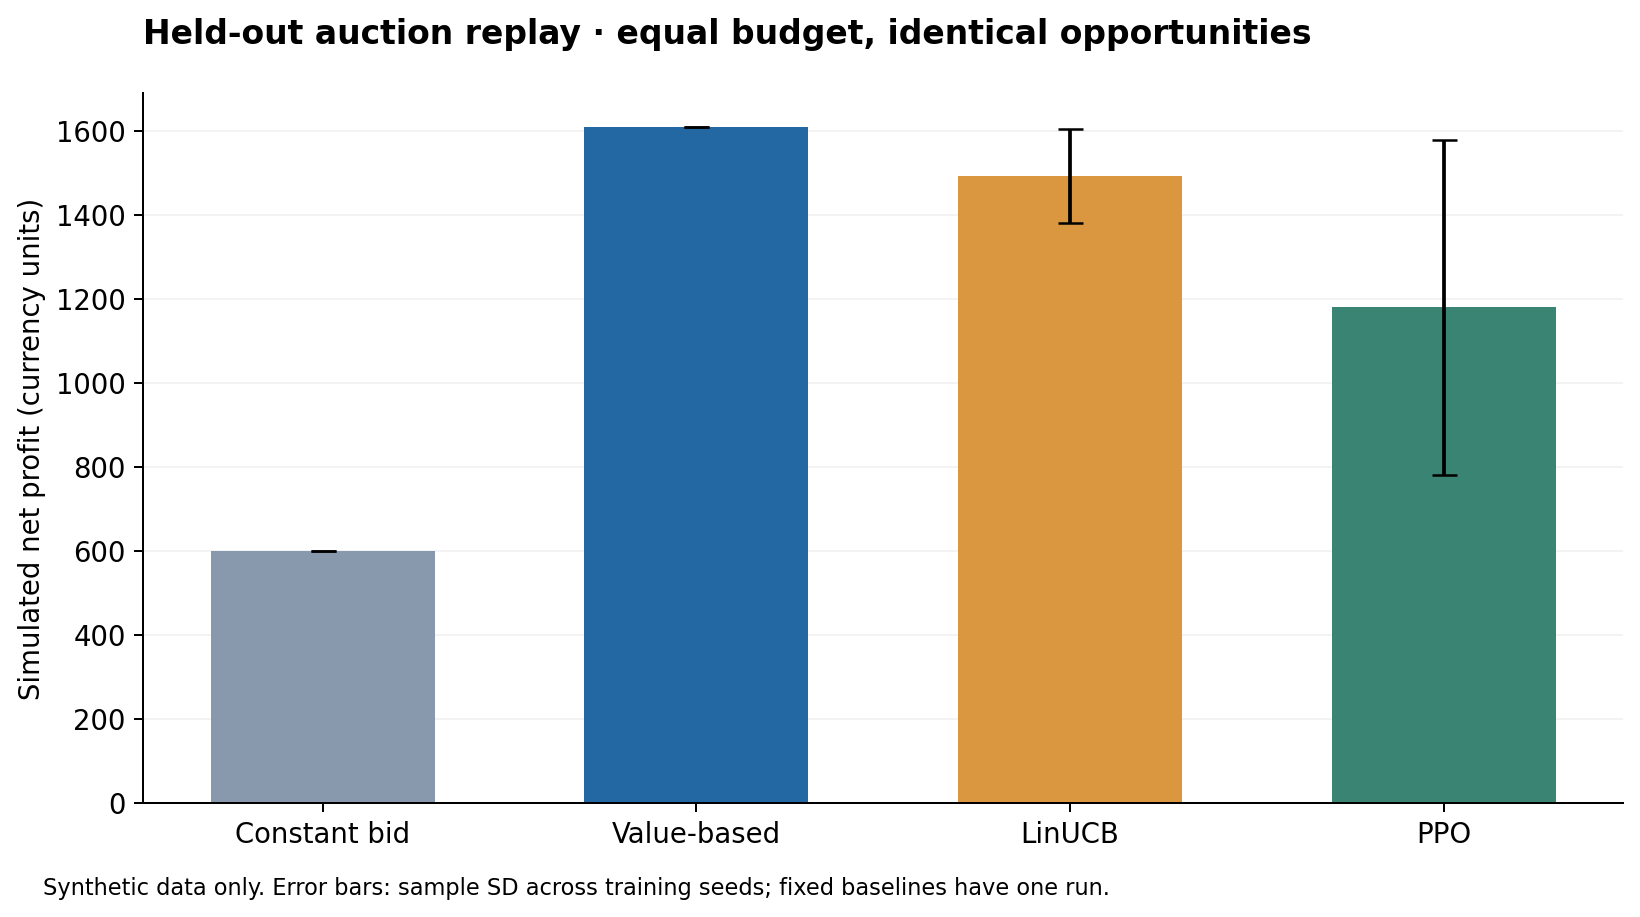

In [4]:
results = pd.read_csv(ROOT / "reports" / "policy_results.csv")
display(results[["policy", "seed", "wins", "conversions", "spend", "profit", "budget_utilization"]].round(3))
display(Image(filename=str(ROOT / "reports" / "policy_comparison.png")))

The value-based baseline earns strong profit while leaving budget unused. LinUCB earns more conversions on average but spends more. PPO varies across seeds and does not beat the value-based baseline on mean profit in this run. These observations motivate additional datasets and budget regimes; they do not establish a universal ranking.

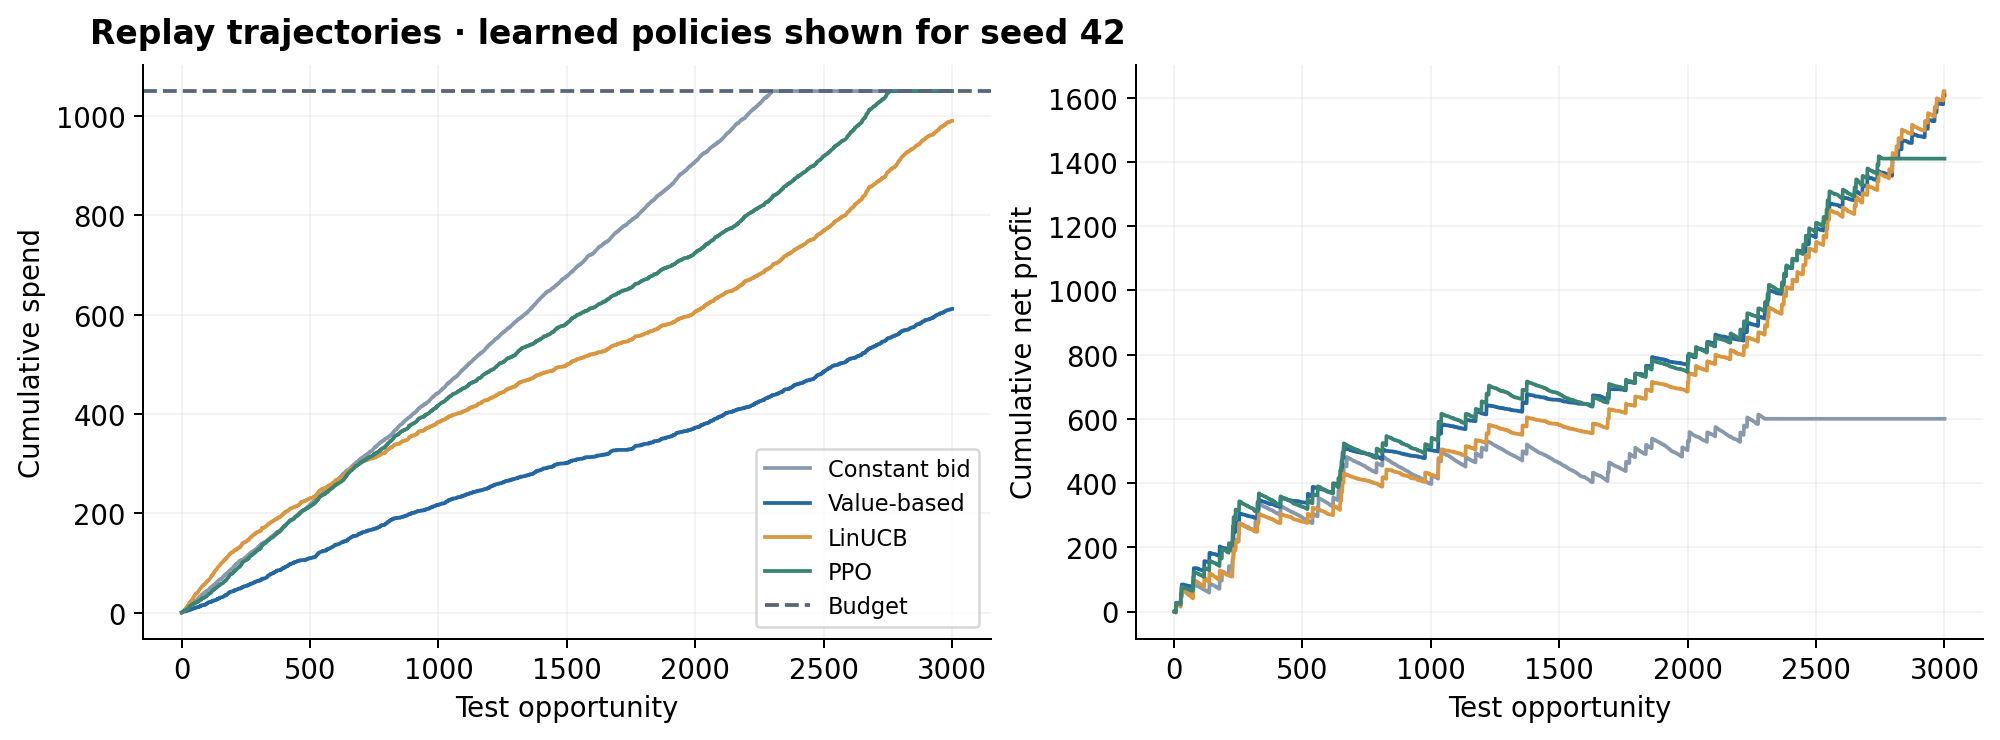

,target,model,split,auc,log_loss,brier,n
0,ctr,logistic,validation,0.6939,0.3617,0.1075,3000
1,ctr,boosted,validation,0.6694,0.3706,0.1100,3000
2,cvr,logistic,validation,0.6850,0.5330,0.1761,392
3,cvr,boosted,validation,0.6562,0.5510,0.1838,392
4,ctr,logistic,test,0.6781,0.3700,0.1098,3000
5,cvr,logistic,test,0.6745,0.5514,0.1843,403


In [5]:
display(Image(filename=str(ROOT / "reports" / "replay_curves.png")))
display(pd.DataFrame(json.loads((ROOT / "reports" / "supervised_metrics.json").read_text())).round(4))

## 4. Send an API request

This local request uses the small models trained above. No running external server or saved model bundle is needed. The API returns a stateless quote capped by the supplied budget.

In [6]:
from tempfile import TemporaryDirectory
from fastapi.testclient import TestClient
from aurorabid.api import create_app
raw = data.opportunities.iloc[[1600]]
history = build_history(raw, data.activity)
row = raw.join(history).iloc[0]
payload = {k: int(row[k]) for k in ["age", "segment", "adslot_id"]}
payload.update({k: float(row[k]) for k in ["floor_price", *history.columns]})
payload.update({"request_id": row.request_id, "timestamp": row.timestamp.isoformat(),
                "remaining_budget": 5., "initial_budget": 100., "time_remaining": .5})
with TemporaryDirectory() as directory:
    save_models(models, directory, {"max_bid": 5., "conversion_value": 30.,
                "value_multiplier": 1., "source_sha256": "notebook-small-demo"})
    with TestClient(create_app(directory)) as client:
        response = client.post("/bid", json=payload)
        assert response.status_code == 200, response.text
        display(response.json())
        exhausted = client.post("/bid", json=dict(payload, remaining_budget=0.)).json()
        assert exhausted["bid"] == 0.
        print("A zero remaining budget produces a zero bid.")

A zero remaining budget produces a zero bid.


{'request_id': 'req001600',
 'bid': 0.8658990859985352,
 'pctr': 0.11124192491222364,
 'pcvr_given_click': 0.2594642552560156,
 'strategy': 'value',
 'model_source_sha256': 'notebook-small-demo'}

## 5. Limits and next questions

- Complete synthetic outcomes enable comparisons that real auction logs cannot support directly.
- Three training seeds share one holdout; they are not independent datasets.
- Training receives immediate rewards; real conversions can arrive later.
- The API does not reserve funds across concurrent requests.

Next experiments: independent datasets, distribution shift, out-of-fold training predictions, optimization baselines, and delayed rewards. The full protocol is in `docs/design.md`.